In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("titanicdataset.csv")
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [3]:
# Checking for the Missing Vaues i.e. find out the Missing Values.

print(df.isnull()) # Null - Values in the form of Boolean Matrix(True - Missing Values , False - Not a mssing Values).
print(df.notnull()) # Opposite of isnull(True - Not a Missing Values , False - Missing Values)
print(df.isnull().sum()) # Count of the Missing Values of each Columns.


     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

In [4]:
# Handling Missing Values in the dataset.

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [5]:
# Handling Duplicates in the Dataset.

print(df.duplicated())  # Reurns a Boolean series i.e. True denotes Duplicate Value and False denotes Not a Duplicate Value.
print(df.duplicated().sum()) # Sum of the Duplicate Values of the rows in the dataset(415 here).
# By illustration, there are no Duplicate Values in the Dataset.

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool
0


In [6]:
# Dropping unnecessary columns from the dataset

df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Display the first few rows to verify
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Univariate Analysis

## Survived Column

In [7]:
# Count of passengers who survived vs not survived
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

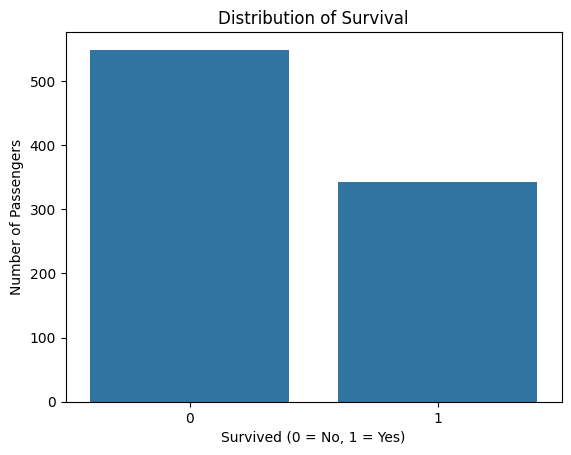

In [8]:
# Plot the distribution of survival
sns.countplot(x='Survived', data=df)

plt.title("Distribution of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

## Pclass(Passenger Class) Column

In [9]:
# Count of passengers in each class
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

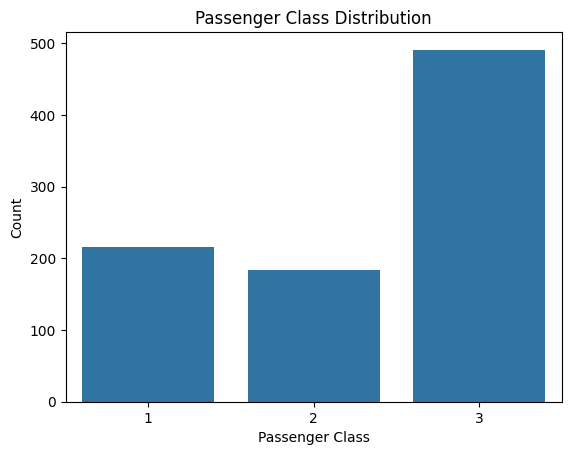

In [10]:
sns.countplot(x='Pclass', data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

## Gender Column

In [11]:
# Gender distribution
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

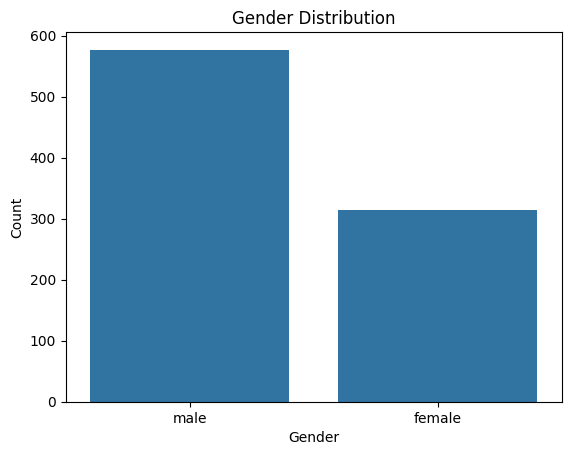

In [12]:
sns.countplot(x='Sex', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## Bivariate Analysis

## Survival vs Passenger Class(Pclass) Columns

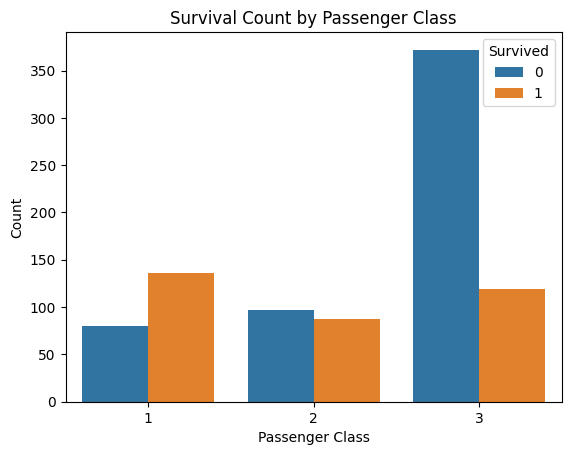

In [13]:
# Countplot shows survival distribution across passenger classes

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

## Survival vs Gender Columns

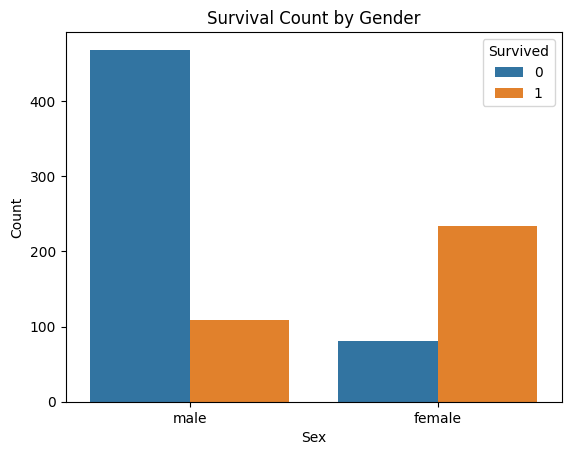

In [14]:
# Countplot to analyze survival based on gender

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

## Correlation Heatmap

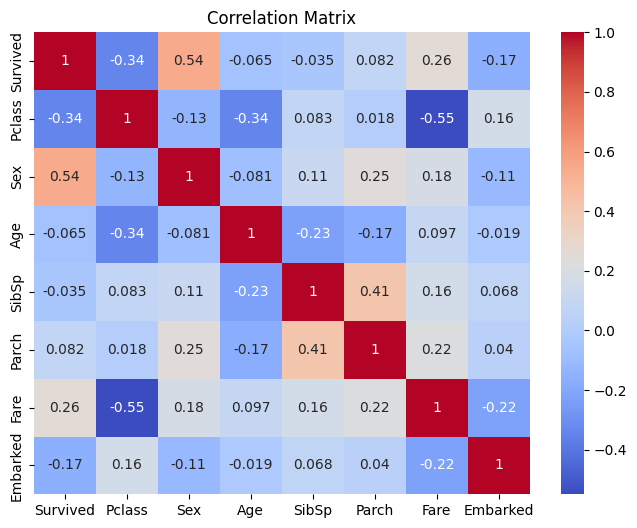

In [15]:
# Convert Sex column to numeric
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

# Convert Embarked column to numeric
df['Embarked'] = df['Embarked'].map({'C':0, 'Q':1, 'S':2})

# Create correlation matrix
corr = df.corr()

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [16]:
# Define Features(X) and Target(y)

# Independent variables
X = df[['Pclass',	'Sex',	'Age',	'SibSp', 'Parch', 'Fare', 'Embarked']]

# Target variable
y = df['Survived']

In [17]:
# Split Dataset into Training and Testing

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Engineering(Data Prepocessing)

In [18]:
# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

## Feature Scaling

## Create and Train Decision Tree Model

In [19]:
# Create Decision Tree Classifier Model
model_DT = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
model_DT.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Evaluation of the Model(Accuracy)

In [20]:
# Predictions on training data
y_train_pred = model_DT.predict(X_train)

# Predictions on testing data
y_test_pred = model_DT.predict(X_test)

# Training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9789325842696629
Testing Accuracy: 0.7821229050279329


In [21]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[84 21]
 [18 56]]


In [22]:
# Detailed metrics
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



## Create and Train Random Forest Model

In [23]:
# Create Random Forest Classifier Model
model_RF = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
model_RF.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Evaluation of the Random Forest Model

In [24]:
# Predictions on training data
y_train_pred_RF = model_RF.predict(X_train)

# Predictions on testing data
y_test_pred_RF = model_RF.predict(X_test)

# Training accuracy
train_accuracy_RF = accuracy_score(y_train, y_train_pred_RF)

# Testing accuracy
test_accuracy_RF = accuracy_score(y_test, y_test_pred_RF)

# Print results
print("Training Accuracy (Random Forest):", train_accuracy_RF)
print("Testing Accuracy (Random Forest):", test_accuracy_RF)

Training Accuracy (Random Forest): 0.9789325842696629
Testing Accuracy (Random Forest): 0.8156424581005587


In [25]:
# Confusion Matrix

cm_RF = confusion_matrix(y_test, y_test_pred_RF)

print("Confusion Matrix (Random Forest):")
print(cm_RF)

Confusion Matrix (Random Forest):
[[90 15]
 [18 56]]


In [26]:
# Detailed metrics

print("Classification Report (Random Forest):")
print(classification_report(y_test, y_test_pred_RF))

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



## Feature Importance(Random Forest)

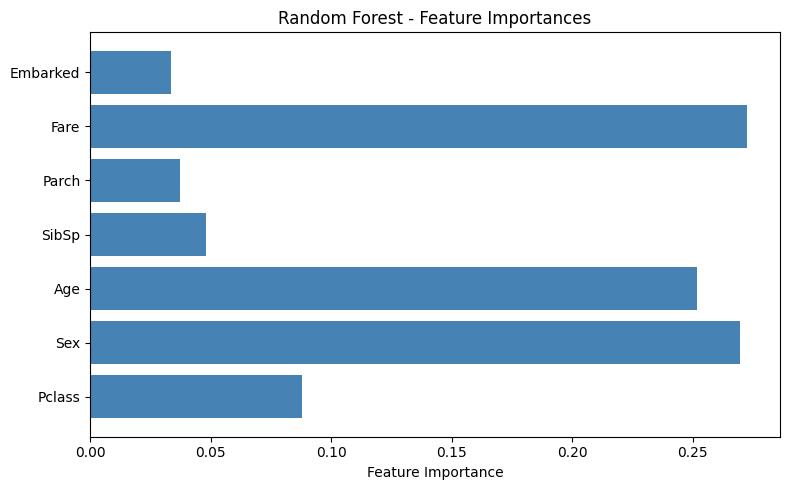

In [27]:
# Get feature importances
feature_names = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
importances = model_RF.feature_importances_

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

## Model Comparison: Decision Tree vs Random Forest

In [28]:
# Compare both models

print("Model Comparison")
print("-" * 45)
print(f"Decision Tree  - Train Accuracy: {train_accuracy:.4f}")
print(f"Decision Tree  - Test Accuracy : {test_accuracy:.4f}")
print("-" * 45)
print(f"Random Forest  - Train Accuracy: {train_accuracy_RF:.4f}")
print(f"Random Forest  - Test Accuracy : {test_accuracy_RF:.4f}")

Model Comparison
---------------------------------------------
Decision Tree  - Train Accuracy: 0.9789
Decision Tree  - Test Accuracy : 0.7821
---------------------------------------------
Random Forest  - Train Accuracy: 0.9789
Random Forest  - Test Accuracy : 0.8156
